# From-Scratch Machine-Learning Preprocessing

This notebook demonstrates reusable NumPy implementations of common preprocessing algorithms and evaluates them in leakage-safe workflows using the Titanic and California Housing datasets.

**Focus:** imputation, categorical encoding, scaling, feature construction, outlier treatment, cross-validation, and visual diagnostics.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="ticks", palette="colorblind")

## Data loading and reproducible splits

The Titanic split is created before any preprocessing. The same rule is used for California Housing so that all fitted statistics come from training data only.

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

titanic = sns.load_dataset("titanic")
anscombe = sns.load_dataset("anscombe")
california = fetch_california_housing(as_frame=True)
california_X = california.data
california_y = california.target

titanic_train, titanic_test = train_test_split(
    titanic,
    test_size=0.2,
    random_state=42,
    stratify=titanic["survived"],
)

cal_X_train, cal_X_test, cal_y_train, cal_y_test = train_test_split(
    california_X,
    california_y,
    test_size=0.2,
    random_state=42,
)

## Missing-value analysis

,missing_count,missing_pct
deck,553,77.668539
age,137,19.241573
embarked,2,0.280899
embark_town,2,0.280899
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


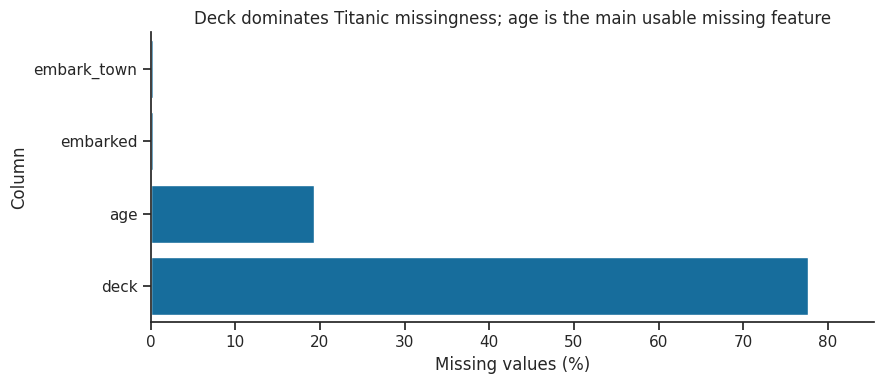

In [3]:
missing_count = titanic_train.isna().sum()
missing_pct = 100 * missing_count / len(titanic_train)
missingness_table = (
    pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct,
    })
    .sort_values("missing_pct", ascending=False)
)
display(missingness_table)

plot_data = (
    missingness_table[missingness_table["missing_count"] > 0]
    .sort_values("missing_pct")
    .reset_index(names="column")
)

fig, ax = plt.subplots(figsize=(9, 4))
base_color = sns.color_palette("colorblind")[0]
sns.barplot(data=plot_data, x="missing_pct", y="column", ax=ax, color=base_color)
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
ax.set_title("Deck dominates Titanic missingness; age is the main usable missing feature")
ax.set_xlim(0, max(5, plot_data["missing_pct"].max() * 1.1))
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / "titanic_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

`age` is most plausibly MAR because its missingness may depend on observed variables such as passenger class, fare, or travelling context. `embarked` has only two missing values in the training split, so MCAR is a reasonable working assumption, although weak MAR through ticketing information is also possible.

## Imputation from scratch

In [4]:
from sklearn.impute import KNNImputer as SklearnKNNImputer
from sklearn.impute import SimpleImputer as SklearnSimpleImputer

from ml_preprocessing.imputers import KNNImputer, SimpleImputer

rng = np.random.default_rng(42)
check_X = rng.normal(size=(8, 3))
check_X[rng.random(check_X.shape) < 0.25] = np.nan

custom_mean = SimpleImputer(strategy="mean").fit_transform(check_X)
sklearn_mean = SklearnSimpleImputer(strategy="mean").fit_transform(check_X)
print("SimpleImputer matches sklearn mean imputer:", np.allclose(custom_mean, sklearn_mean))

knn_train = np.array([
    [1.0, 1.0],
    [2.0, 2.0],
    [10.0, 10.0],
    [11.0, 11.0],
])
knn_missing = np.array([
    [np.nan, 1.4],
    [10.6, np.nan],
])
custom_knn = KNNImputer(k=2).fit(knn_train).transform(knn_missing)
sklearn_knn = SklearnKNNImputer(n_neighbors=2).fit(knn_train).transform(knn_missing)

knn_comparison = pd.DataFrame({
    "custom_x0": custom_knn[:, 0],
    "custom_x1": custom_knn[:, 1],
    "sklearn_x0": sklearn_knn[:, 0],
    "sklearn_x1": sklearn_knn[:, 1],
})
display(knn_comparison)
print("Maximum absolute KNN difference:", np.max(np.abs(custom_knn - sklearn_knn)))

titanic_clean_train = titanic_train.copy()
titanic_clean_test = titanic_test.copy()

for frame in (titanic_clean_train, titanic_clean_test):
    frame["age_missing"] = frame["age"].isna().astype(int)

age_context_cols = ["age", "pclass", "fare"]
age_imputer = KNNImputer(k=5).fit(titanic_clean_train[age_context_cols])
titanic_clean_train["age_imputed"] = age_imputer.transform(
    titanic_clean_train[age_context_cols]
)[:, 0]
titanic_clean_test["age_imputed"] = age_imputer.transform(
    titanic_clean_test[age_context_cols]
)[:, 0]

embarked_mode = titanic_clean_train["embarked"].mode(dropna=True).iloc[0]
titanic_clean_train["embarked_imputed"] = titanic_clean_train["embarked"].fillna(embarked_mode)
titanic_clean_test["embarked_imputed"] = titanic_clean_test["embarked"].fillna(embarked_mode)

display(
    titanic_clean_train[["age", "age_missing", "age_imputed", "embarked", "embarked_imputed"]]
    .head(10)
)

SimpleImputer matches sklearn mean imputer: True


,custom_x0,custom_x1,sklearn_x0,sklearn_x1
0,1.5,1.4,1.5,1.4
1,10.6,10.5,10.6,10.5


Maximum absolute KNN difference: 0.0


,age,age_missing,age_imputed,embarked,embarked_imputed
692,NaN,1,33.4,S,S
481,NaN,1,36.4,S,S
527,NaN,1,33.6,S,S
855,18.0,0,18.0,S,S
801,31.0,0,31.0,S,S
652,21.0,0,21.0,S,S
509,26.0,0,26.0,S,S
557,NaN,1,33.6,C,C
828,NaN,1,34.9,Q,Q
18,31.0,0,31.0,S,S


The two KNN implementations give the same values on this small example. Differences can appear on other data because sklearn uses a NaN-aware distance normalization, while my simplified version uses ordinary Euclidean distance over the coordinates shared by a row and a candidate neighbour.

Leakage is avoided by fitting the age imputer and the embarked mode on `titanic_train` only, then reusing those fitted values on `titanic_test`. The `age_missing` indicator is created before imputation.

## Categorical encoding

In [5]:
from ml_preprocessing.encoders import OneHotEncoder, TargetEncoder

categorical_cols = ["sex", "embarked_imputed"]
one_hot_encoder = OneHotEncoder(drop="first").fit(titanic_clean_train[categorical_cols])
one_hot_train = pd.DataFrame(
    one_hot_encoder.transform(titanic_clean_train[categorical_cols]),
    columns=one_hot_encoder.get_feature_names_out(),
    index=titanic_clean_train.index,
)
display(one_hot_train.head())

target_encoder = TargetEncoder(smoothing=5.0)
embarked_oof = target_encoder.fit_transform_cv(
    titanic_clean_train[["embarked_imputed"]],
    titanic_clean_train["survived"],
    cv=5,
    random_state=42,
)
embarked_levels = pd.DataFrame({
    "embarked_imputed": sorted(titanic_clean_train["embarked_imputed"].unique())
})
embarked_level_encoding = pd.concat(
    [
        embarked_levels,
        pd.DataFrame(
            target_encoder.transform(embarked_levels),
            columns=["target_encoded_survival_rate"],
        ),
    ],
    axis=1,
)
display(embarked_level_encoding)

target_encoding_demo = titanic_clean_train[["embarked_imputed", "survived"]].copy()
target_encoding_demo["embarked_target_oof"] = embarked_oof[:, 0]
display(target_encoding_demo.head(10))


,sex_female,embarked_imputed_C,embarked_imputed_Q
692,0.0,0.0,0.0
481,0.0,0.0,0.0
527,0.0,0.0,0.0
855,1.0,0.0,0.0
801,1.0,0.0,0.0


,embarked_imputed,target_encoded_survival_rate
0,C,0.554980
1,Q,0.431952
2,S,0.330625


,embarked_imputed,survived,embarked_target_oof
692,S,1,0.341988
481,S,0,0.328356
527,S,0,0.341988
855,S,1,0.325107
801,S,1,0.324457
652,S,0,0.328356
509,S,1,0.333953
557,C,0,0.580522
828,Q,1,0.406015
18,S,0,0.341988


Fitting a target encoder before splitting would use survival outcomes from validation or test rows when category means are calculated. The out-of-fold encoding above prevents that: each training row is encoded from other folds, and unseen categories fall back to the training global mean.

## Impact of data cleaning

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

raw_cols = ["pclass", "age", "sibsp", "parch", "fare", "sex"]
raw_train = titanic_train[raw_cols + ["survived"]].dropna()
raw_test = titanic_test[raw_cols + ["survived"]].dropna()

X_raw_train = raw_train[raw_cols].copy()
X_raw_test = raw_test[raw_cols].copy()
X_raw_train["sex"] = X_raw_train["sex"].map({"female": 0, "male": 1}).astype(float)
X_raw_test["sex"] = X_raw_test["sex"].map({"female": 0, "male": 1}).astype(float)

raw_model = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
raw_model.fit(X_raw_train, raw_train["survived"])
raw_pred = raw_model.predict(X_raw_test)

clean_num_cols = ["pclass", "age_imputed", "sibsp", "parch", "fare", "age_missing"]
clean_cat_cols = ["sex", "embarked_imputed"]
clean_encoder = OneHotEncoder(drop="first").fit(titanic_clean_train[clean_cat_cols])


def build_clean_titanic_features(frame):
    numeric = frame[clean_num_cols].astype(float)
    encoded = pd.DataFrame(
        clean_encoder.transform(frame[clean_cat_cols]),
        columns=clean_encoder.get_feature_names_out(),
        index=frame.index,
    )
    return pd.concat([numeric, encoded], axis=1)


X_clean_train = build_clean_titanic_features(titanic_clean_train)
X_clean_test = build_clean_titanic_features(titanic_clean_test)

clean_model = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
clean_model.fit(X_clean_train, titanic_clean_train["survived"])
clean_pred = clean_model.predict(X_clean_test)

cleaning_results = pd.DataFrame(
    [
        {
            "model": "raw_drop_missing",
            "train_rows": len(X_raw_train),
            "test_rows": len(X_raw_test),
            "accuracy": accuracy_score(raw_test["survived"], raw_pred),
            "f1": f1_score(raw_test["survived"], raw_pred),
        },
        {
            "model": "clean_imputed_one_hot",
            "train_rows": len(X_clean_train),
            "test_rows": len(X_clean_test),
            "accuracy": accuracy_score(titanic_clean_test["survived"], clean_pred),
            "f1": f1_score(titanic_clean_test["survived"], clean_pred),
        },
    ]
)
display(cleaning_results)


,model,train_rows,test_rows,accuracy,f1
0,raw_drop_missing,575,139,0.805755,0.737864
1,clean_imputed_one_hot,712,179,0.804469,0.724409


The cleaned model uses every training row, but its held-out accuracy and F1 are slightly lower than the drop-missing baseline. This is a useful result rather than a failure: imputation preserves data, but approximate ages can add noise, and the two models are evaluated on test sets of different sizes. Cleaning improves completeness and pipeline safety, but it does not guarantee a higher score on one split.

## Feature scaling from scratch

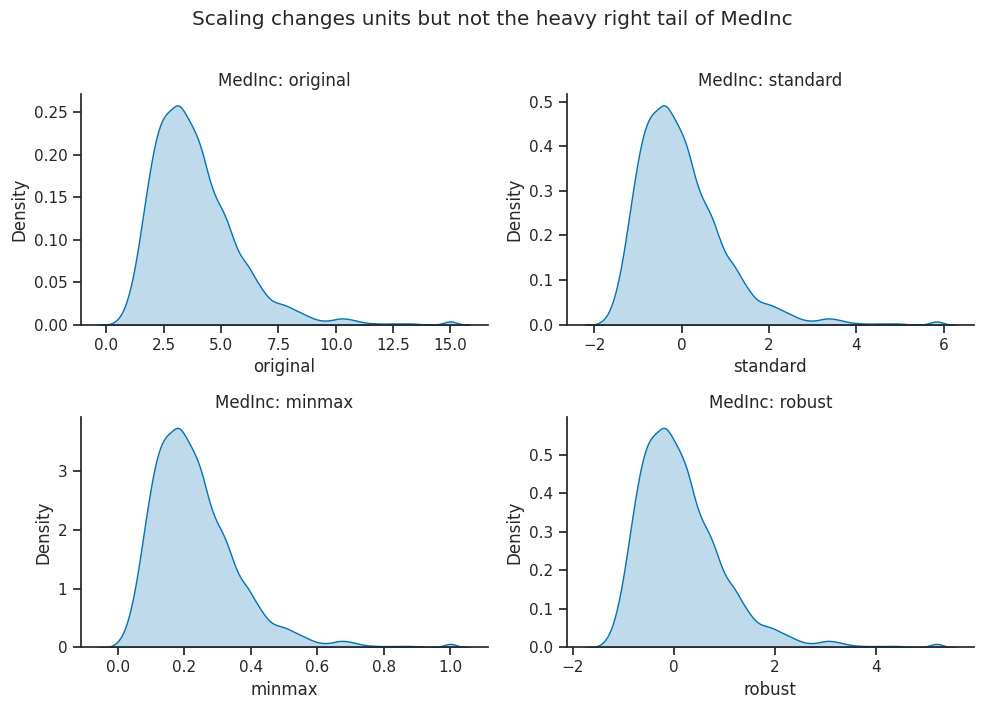

In [7]:
from ml_preprocessing.scalers import MinMaxScaler, RobustScaler, StandardScaler

cal_scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}
cal_scaled = {}
medinc_idx = list(cal_X_train.columns).index("MedInc")

for name, scaler in cal_scalers.items():
    scaler.fit(cal_X_train)
    cal_scaled[name] = {
        "train": scaler.transform(cal_X_train),
        "test": scaler.transform(cal_X_test),
    }

medinc_versions = {
    "original": cal_X_train["MedInc"].to_numpy(),
    "standard": cal_scaled["standard"]["train"][:, medinc_idx],
    "minmax": cal_scaled["minmax"]["train"][:, medinc_idx],
    "robust": cal_scaled["robust"]["train"][:, medinc_idx],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
base_color = sns.color_palette("colorblind")[0]
for ax, (label, values) in zip(axes.ravel(), medinc_versions.items()):
    sns.kdeplot(x=values, ax=ax, fill=True, color=base_color)
    ax.set_title(f"MedInc: {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    sns.despine(ax=ax)

fig.suptitle("Scaling changes units but not the heavy right tail of MedInc", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "california_medinc_scaling_kde.png", dpi=300, bbox_inches="tight")
plt.show()

Robust scaling is least affected by the heavy right tail because it uses the median and interquartile range. Standard scaling depends on the mean and standard deviation, while min-max scaling depends directly on the extreme values.

## Polynomial and interaction features

In [8]:
from ml_preprocessing.feature_creation import KBinsDiscretizer, PolynomialFeatures

poly_cols = ["MedInc", "AveRooms"]
poly = PolynomialFeatures(degree=2, include_bias=True).fit(cal_X_train[poly_cols])


def polynomial_names(columns, powers):
    names = []
    for power in powers:
        terms = []
        for column, exponent in zip(columns, power):
            if exponent == 1:
                terms.append(column)
            elif exponent > 1:
                terms.append(f"{column}^{exponent}")
        names.append("bias" if not terms else "*".join(terms))
    return names


poly_names = polynomial_names(poly_cols, poly.powers_)
point = np.array([[3.0, 5.0]])
point_transformed = pd.DataFrame(poly.transform(point), columns=poly_names)
display(point_transformed)

poly_train_preview = pd.DataFrame(
    poly.transform(cal_X_train[poly_cols].head()),
    columns=poly_names,
    index=cal_X_train.head().index,
)
display(poly_train_preview)


,bias,MedInc,AveRooms,MedInc^2,MedInc*AveRooms,AveRooms^2
0,1.0,3.0,5.0,9.0,15.0,25.0


,bias,MedInc,AveRooms,MedInc^2,MedInc*AveRooms,AveRooms^2
14196,1.0,3.2596,5.017657,10.624992,16.355553,25.176877
8267,1.0,3.8125,4.473545,14.535156,17.055390,20.012605
17445,1.0,4.1563,5.645833,17.274830,23.465777,31.875434
14265,1.0,1.9425,4.002817,3.773306,7.775472,16.022543
2271,1.0,3.5542,6.268421,12.632338,22.279222,39.293102


An interaction term captures a joint effect that is not represented by two separate linear terms. `MedInc*AveRooms`, for example, allows the relationship between room count and house value to change across income levels.

## Feature discretisation

,bin,uniform_count,quantile_count
0,0,1783,1652
1,1,5928,1651
2,2,4855,1651
3,3,2436,1651
4,4,859,1651
5,5,350,1649
6,6,143,1652
7,7,70,1652
8,8,37,1651
9,9,51,1652


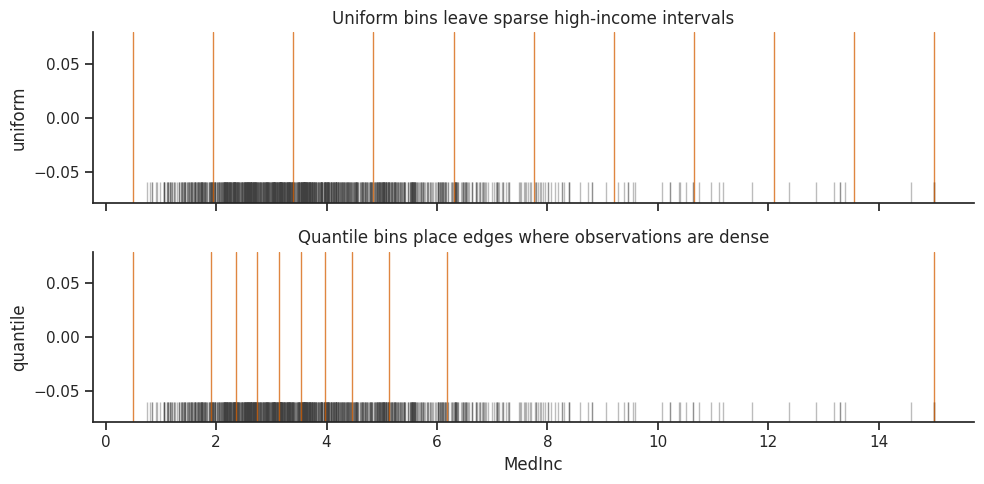

In [9]:
medinc_train = cal_X_train[["MedInc"]]
binners = {
    "uniform": KBinsDiscretizer(n_bins=10, strategy="uniform").fit(medinc_train),
    "quantile": KBinsDiscretizer(n_bins=10, strategy="quantile").fit(medinc_train),
}

uniform_bins = binners["uniform"].transform(medinc_train)
quantile_bins = binners["quantile"].transform(medinc_train)
bin_counts = pd.DataFrame({
    "bin": np.arange(10),
    "uniform_count": uniform_bins.sum(axis=0).astype(int),
    "quantile_count": quantile_bins.sum(axis=0).astype(int),
})
display(bin_counts)

medinc_sample = cal_X_train["MedInc"].sample(
    n=min(1200, len(cal_X_train)),
    random_state=42,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
edge_color = sns.color_palette("colorblind")[3]
for ax, (name, binner) in zip(axes, binners.items()):
    sns.rugplot(x=medinc_sample, ax=ax, height=0.12, color="0.25", alpha=0.35)
    for edge in binner.bin_edges_[0]:
        ax.axvline(edge, color=edge_color, alpha=0.75, linewidth=1)
    ax.set_ylabel(name)
    sns.despine(ax=ax)

axes[0].set_title("Uniform bins leave sparse high-income intervals")
axes[1].set_title("Quantile bins place edges where observations are dense")
axes[-1].set_xlabel("MedInc")
fig.tight_layout()
fig.savefig(FIG_DIR / "california_medinc_bins.png", dpi=300, bbox_inches="tight")
plt.show()

Quantile binning gives the more balanced bin sizes because its edges are fitted at equal-frequency percentiles. Balanced bins give each indicator a similar amount of training evidence; uniform bins can leave tail categories supported by only a few observations.

## Impact of feature engineering

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score


def cv_rmse_for_builder(X, y, feature_builder, n_splits=5):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True).to_numpy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmses = []

    for train_idx, valid_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_train_fold = y[train_idx]
        y_valid_fold = y[valid_idx]

        X_train_features, X_valid_features = feature_builder(X_train_fold, X_valid_fold)
        model = LinearRegression()
        model.fit(X_train_features, y_train_fold)
        predictions = model.predict(X_valid_features)
        rmses.append(np.sqrt(np.mean((predictions - y_valid_fold) ** 2)))

    return float(np.mean(rmses)), float(np.std(rmses))


def raw_standardized_builder(X_train_fold, X_valid_fold):
    scaler = StandardScaler().fit(X_train_fold)
    return scaler.transform(X_train_fold), scaler.transform(X_valid_fold)


def polynomial_builder(X_train_fold, X_valid_fold):
    scaler = StandardScaler().fit(X_train_fold)
    X_train_scaled = scaler.transform(X_train_fold)
    X_valid_scaled = scaler.transform(X_valid_fold)
    poly_features = PolynomialFeatures(degree=2, include_bias=False).fit(X_train_scaled)
    return poly_features.transform(X_train_scaled), poly_features.transform(X_valid_scaled)


def binned_medinc_builder(X_train_fold, X_valid_fold):
    scaler = StandardScaler().fit(X_train_fold)
    X_train_scaled = scaler.transform(X_train_fold)
    X_valid_scaled = scaler.transform(X_valid_fold)
    binner = KBinsDiscretizer(n_bins=10, strategy="quantile").fit(X_train_fold[["MedInc"]])
    X_train_bins = binner.transform(X_train_fold[["MedInc"]])
    X_valid_bins = binner.transform(X_valid_fold[["MedInc"]])
    return np.hstack([X_train_scaled, X_train_bins]), np.hstack([X_valid_scaled, X_valid_bins])


feature_versions = {
    "raw_standardized": raw_standardized_builder,
    "standardized_plus_degree2": polynomial_builder,
    "standardized_plus_quantile_binned_MedInc": binned_medinc_builder,
}

feature_engineering_results = []
for version, builder in feature_versions.items():
    mean_rmse, std_rmse = cv_rmse_for_builder(cal_X_train, cal_y_train, builder)
    feature_engineering_results.append({
        "feature_version": version,
        "cv_rmse_mean": mean_rmse,
        "cv_rmse_std": std_rmse,
    })

feature_engineering_results = pd.DataFrame(feature_engineering_results)
display(feature_engineering_results.sort_values("cv_rmse_mean"))


,feature_version,cv_rmse_mean,cv_rmse_std
2,standardized_plus_quantile_binned_MedInc,0.708697,0.012967
0,raw_standardized,0.720510,0.013895
1,standardized_plus_degree2,1.390345,1.379680


Equal-frequency binning of `MedInc` performs best in this comparison, reducing mean CV RMSE from about 0.721 to 0.709. The degree-2 expansion performs much worse and is unstable across folds. Squared terms amplify extreme California Housing values and create strong collinearity, so adding flexibility without regularisation does not help this OLS model.

## Anscombe's Quartet

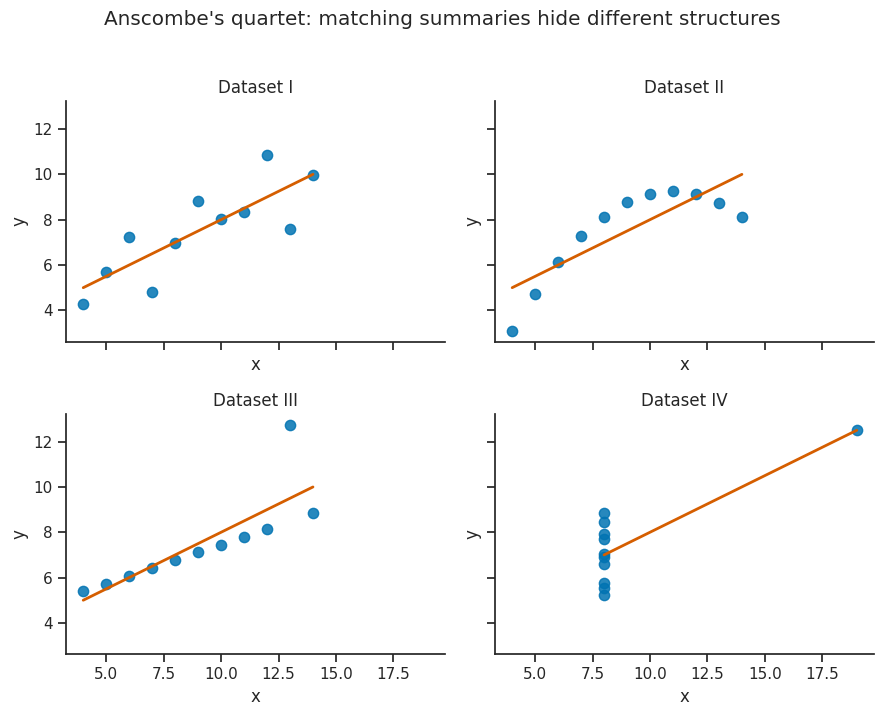

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
line_color = sns.color_palette("colorblind")[3]

for ax, (dataset, group) in zip(axes.ravel(), anscombe.groupby("dataset")):
    sns.regplot(
        data=group,
        x="x",
        y="y",
        ci=None,
        scatter_kws={"s": 55, "alpha": 0.85},
        line_kws={"color": line_color, "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"Dataset {dataset}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    sns.despine(ax=ax)

fig.suptitle("Anscombe's quartet: matching summaries hide different structures", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "anscombe_quartet.png", dpi=300, bbox_inches="tight")
plt.show()

The four datasets have almost identical means, variances, correlations, and fitted regression lines, yet they should not be interpreted in the same way. Dataset I is roughly linear, II follows a curved pattern, III is distorted by one large outlier, and IV is dominated by a high-leverage point. The plots reveal model problems that the summary statistics hide.

## Titanic exploratory visualisations

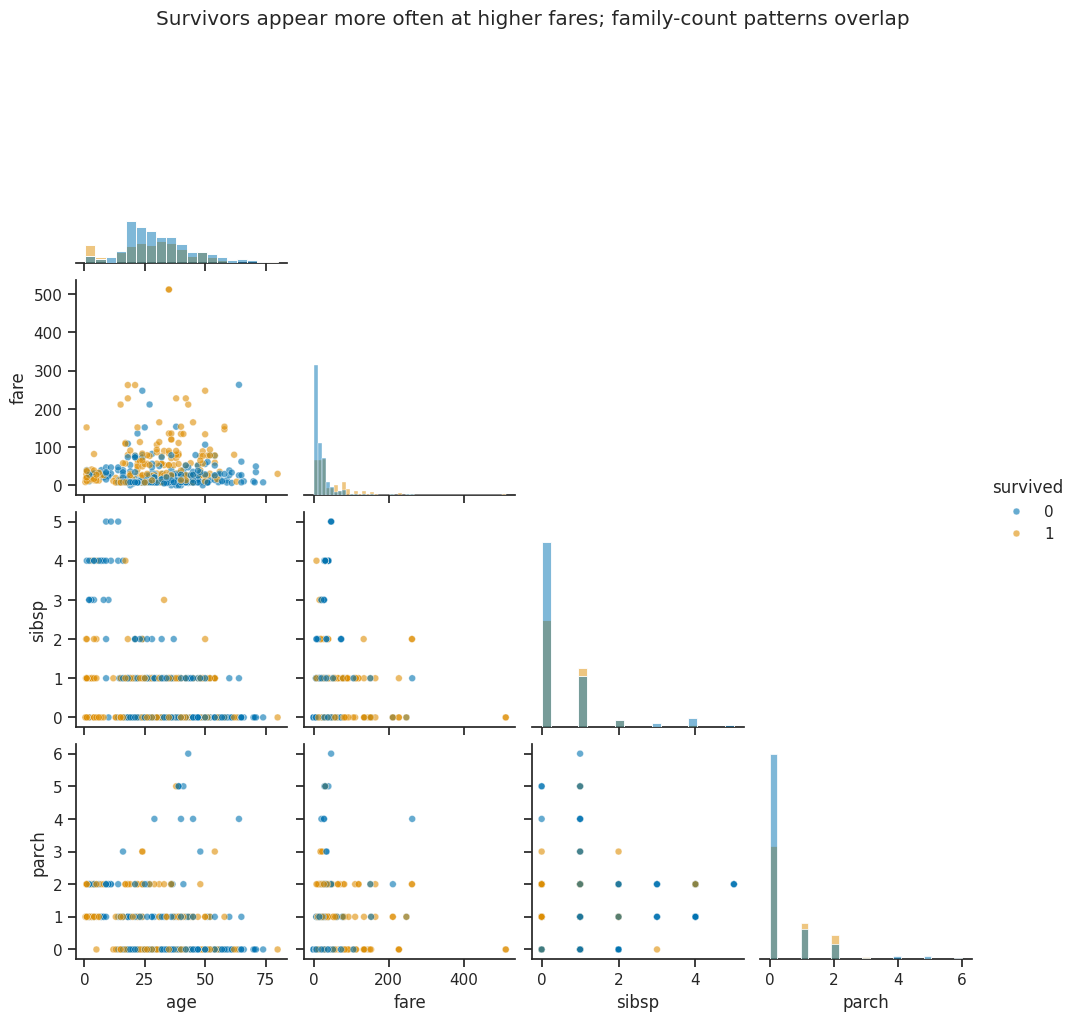

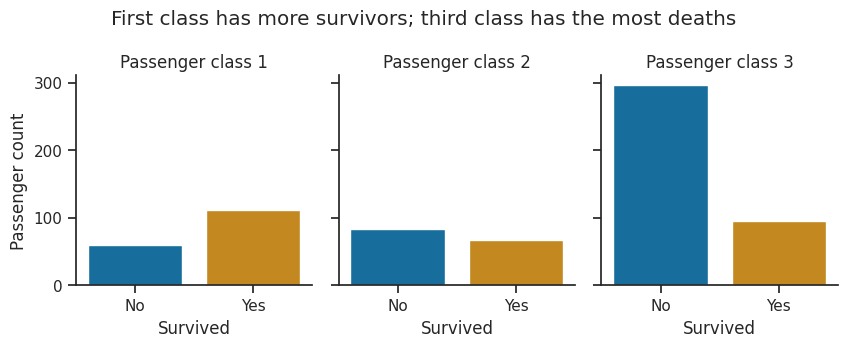

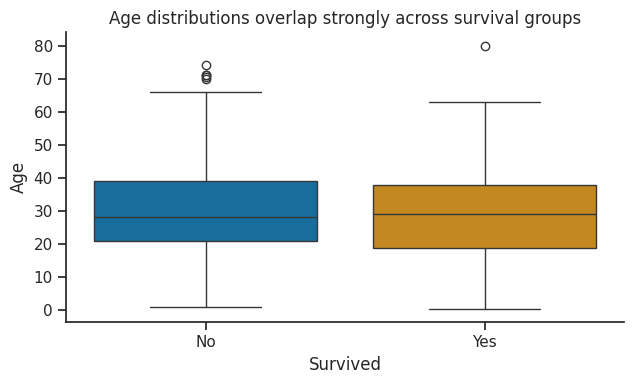

In [12]:
pair_data = titanic_train[["age", "fare", "sibsp", "parch", "survived"]].dropna()
pair_grid = sns.pairplot(
    pair_data,
    vars=["age", "fare", "sibsp", "parch"],
    hue="survived",
    corner=True,
    diag_kind="hist",
    palette="colorblind",
    plot_kws={"alpha": 0.60, "s": 24},
)
pair_grid.fig.suptitle(
    "Survivors appear more often at higher fares; family-count patterns overlap",
    y=1.02,
)
pair_grid.savefig(FIG_DIR / "titanic_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

survival_by_class = sns.catplot(
    data=titanic_train,
    x="survived",
    col="pclass",
    kind="count",
    hue="survived",
    palette="colorblind",
    legend=False,
    height=3.2,
    aspect=0.9,
)
survival_by_class.set_axis_labels("Survived", "Passenger count")
survival_by_class.set_xticklabels(["No", "Yes"])
survival_by_class.set_titles("Passenger class {col_name}")
survival_by_class.fig.suptitle(
    "First class has more survivors; third class has the most deaths",
    y=1.08,
)
survival_by_class.savefig(FIG_DIR / "titanic_survival_by_pclass.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.boxplot(
    data=titanic_train,
    x="survived",
    y="age",
    hue="survived",
    palette="colorblind",
    legend=False,
    ax=ax,
)
ax.set_title("Age distributions overlap strongly across survival groups")
ax.set_xlabel("Survived")
ax.set_ylabel("Age")
ax.set_xticks([0, 1], ["No", "Yes"])
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / "titanic_age_by_survival_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualisation principles

I kept the data-ink ratio high by removing decorative elements and using only light axes, points, bars, fitted lines, and bin boundaries. Titles state the main observation instead of repeating the variable names.

Position and length carry the main comparisons because they are easier to judge accurately than hue or area. Colour is used only to separate survival groups. After applying these principles, I would further reduce overplotting in the pair plot, either with more transparency or a carefully chosen sample for the final report.

## Leakage-safe preprocessing pipeline

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline


class TitanicPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_df = X.copy()
        self.age_imputer_ = SimpleImputer(strategy="median").fit(X_df[["age"]])
        self.embarked_mode_ = X_df["embarked"].mode(dropna=True).iloc[0]

        cat_frame = X_df[["sex", "embarked"]].copy()
        cat_frame["embarked"] = cat_frame["embarked"].fillna(self.embarked_mode_)
        self.encoder_ = OneHotEncoder(drop="first").fit(cat_frame)

        numeric_frame = self._numeric_frame(X_df)
        self.scaler_ = StandardScaler().fit(numeric_frame)
        self.feature_names_out_ = list(numeric_frame.columns) + self.encoder_.get_feature_names_out()
        return self

    def transform(self, X):
        X_df = X.copy()
        numeric_frame = self._numeric_frame(X_df)
        numeric_scaled = self.scaler_.transform(numeric_frame)

        cat_frame = X_df[["sex", "embarked"]].copy()
        cat_frame["embarked"] = cat_frame["embarked"].fillna(self.embarked_mode_)
        encoded = self.encoder_.transform(cat_frame)

        return np.hstack([numeric_scaled, encoded])

    def _numeric_frame(self, X_df):
        age_imputed = self.age_imputer_.transform(X_df[["age"]])[:, 0]
        return pd.DataFrame(
            {
                "pclass": X_df["pclass"].astype(float),
                "age": age_imputed,
                "sibsp": X_df["sibsp"].astype(float),
                "parch": X_df["parch"].astype(float),
                "fare": X_df["fare"].astype(float),
                "age_missing": X_df["age"].isna().astype(float),
            },
            index=X_df.index,
        )


titanic_pipeline = Pipeline(
    [
        ("preprocess", TitanicPreprocessor()),
        ("model", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)),
    ]
)

titanic_pipeline_X = titanic_train[["pclass", "age", "sibsp", "parch", "fare", "sex", "embarked"]]
titanic_pipeline_y = titanic_train["survived"].to_numpy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline_scores = cross_val_score(
    titanic_pipeline,
    titanic_pipeline_X,
    titanic_pipeline_y,
    cv=cv,
    scoring="accuracy",
)

print(f"5-fold CV accuracy: {pipeline_scores.mean():.3f} +/- {pipeline_scores.std():.3f}")
display(pd.DataFrame({"fold": np.arange(1, 6), "accuracy": pipeline_scores}))


5-fold CV accuracy: 0.796 +/- 0.025


,fold,accuracy
0,1,0.783217
1,2,0.790210
2,3,0.816901
3,4,0.760563
4,5,0.830986


## Data-leakage checklist

- **Imputation:** fitting age statistics on the full Titanic dataset would let held-out rows influence training features. I split first and fit only on training rows or training folds.
- **Target encoding:** category means calculated before splitting would include held-out survival labels. Training rows are encoded out of fold.
- **Scaling:** a scaler fitted before cross-validation would use validation-fold means and spreads. Each CV fold fits its own scaler.
- **Winsorisation:** full-data percentiles would reveal the held-out distribution. The 1st and 99th percentile cutoffs are fitted on each training fold and then applied to its validation fold.

## Outlier treatment

In [14]:
def clip_medinc_with_training_cutoffs(X_train_frame, X_apply_frame):
    lower, upper = X_train_frame["MedInc"].quantile([0.01, 0.99])
    clipped = X_apply_frame.copy()
    clipped["MedInc"] = clipped["MedInc"].clip(lower=lower, upper=upper)
    return clipped, float(lower), float(upper)


cal_X_train_winsor, medinc_p01, medinc_p99 = clip_medinc_with_training_cutoffs(
    cal_X_train,
    cal_X_train,
)
cal_X_test_winsor, _, _ = clip_medinc_with_training_cutoffs(cal_X_train, cal_X_test)


def fit_standardized_ols(X_frame, y):
    scaler = StandardScaler().fit(X_frame)
    X_scaled = scaler.transform(X_frame)
    model = LinearRegression().fit(X_scaled, y)
    return model, scaler


base_ols, base_scaler = fit_standardized_ols(cal_X_train, cal_y_train)
winsor_ols, winsor_scaler = fit_standardized_ols(cal_X_train_winsor, cal_y_train)


def cv_rmse_winsorized(X, y, winsorize=False):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True).to_numpy()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []

    for train_idx, valid_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx].copy()
        X_valid_fold = X.iloc[valid_idx].copy()

        if winsorize:
            X_train_fold, lower, upper = clip_medinc_with_training_cutoffs(
                X_train_fold,
                X_train_fold,
            )
            X_valid_fold = X_valid_fold.copy()
            X_valid_fold["MedInc"] = X_valid_fold["MedInc"].clip(lower=lower, upper=upper)

        scaler = StandardScaler().fit(X_train_fold)
        X_train_scaled = scaler.transform(X_train_fold)
        X_valid_scaled = scaler.transform(X_valid_fold)
        model = LinearRegression().fit(X_train_scaled, y[train_idx])
        predictions = model.predict(X_valid_scaled)
        rmses.append(np.sqrt(np.mean((predictions - y[valid_idx]) ** 2)))

    return float(np.mean(rmses)), float(np.std(rmses))


base_rmse_mean, base_rmse_std = cv_rmse_winsorized(cal_X_train, cal_y_train, winsorize=False)
winsor_rmse_mean, winsor_rmse_std = cv_rmse_winsorized(cal_X_train, cal_y_train, winsorize=True)
medinc_column_idx = list(cal_X_train.columns).index("MedInc")

winsor_results = pd.DataFrame(
    [
        {
            "version": "original",
            "MedInc_coefficient": base_ols.coef_[medinc_column_idx],
            "cv_rmse_mean": base_rmse_mean,
            "cv_rmse_std": base_rmse_std,
        },
        {
            "version": "winsorized_1_99",
            "MedInc_coefficient": winsor_ols.coef_[medinc_column_idx],
            "cv_rmse_mean": winsor_rmse_mean,
            "cv_rmse_std": winsor_rmse_std,
        },
    ]
)

print(f"Training-only MedInc cutoffs: p01={medinc_p01:.3f}, p99={medinc_p99:.3f}")
display(winsor_results)


Training-only MedInc cutoffs: p01=1.067, p99=10.577


,version,MedInc_coefficient,cv_rmse_mean,cv_rmse_std
0,original,0.854383,0.720510,0.013895
1,winsorized_1_99,0.902200,0.706905,0.013911


Winsorising `MedInc` improves mean CV RMSE from about 0.721 to 0.707 and changes the standardised `MedInc` coefficient from 0.854 to 0.902. The clipped model is less controlled by the most extreme income values, so the coefficient is estimated from a range with more training support. Winsorisation can improve generalisation when extremes have high leverage, but it should be fitted on training data and checked by validation rather than applied automatically.

## Yeo-Johnson power transformation

The transformer estimates one lambda value by maximum likelihood and applies the fitted transformation to `MedInc`.

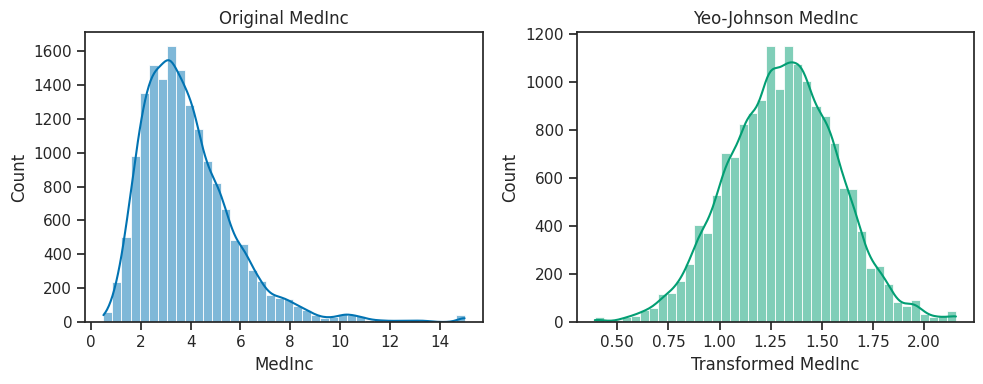

Estimated lambda for MedInc: -0.190


In [15]:
from ml_preprocessing.power_transformers import YeoJohnsonTransformer


yeo_johnson = YeoJohnsonTransformer().fit(cal_X_train[["MedInc"]])
medinc_yj = yeo_johnson.transform(cal_X_train[["MedInc"]])[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(cal_X_train["MedInc"], bins=40, kde=True, ax=axes[0], color=sns.color_palette("colorblind")[0])
axes[0].set_title("Original MedInc")
axes[0].set_xlabel("MedInc")
sns.histplot(medinc_yj, bins=40, kde=True, ax=axes[1], color=sns.color_palette("colorblind")[2])
axes[1].set_title("Yeo-Johnson MedInc")
axes[1].set_xlabel("Transformed MedInc")
fig.tight_layout()
fig.savefig(FIG_DIR / "california_medinc_yeojohnson.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Estimated lambda for MedInc: {yeo_johnson.lambdas_[0]:.3f}")
